<a href="https://colab.research.google.com/github/wlobos1980/Machine_Learning/blob/main/Mi_Primer_Modelo_ML_WL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Etapas de un problema de Machine Learning**

* **Definir el problema:** Que se pretende predecir? o Que datos es necesario conseguir?
* **Explorar y entender** los datos para crear el modelo
* **Metrica de exito:** Definir una apropiada de cuantificar como de buenos son los resultados.
* **Preparar la estrategia para evaluar el modelo:** Separar las observaciones (filas) en conjunto de datos de entrenamiento, un conjunto de validacion (validacion cruzada) y un conjunto de test. Es muy importe asegurar que ninguna informacion del conjunto de test participa en el proceso de entrenamiento.
* **Preprocesamiento de Datos:** Aplicar las transformaciones necesarias para que los datos puedan ser interpretados por el algoritmo de machine learning seleccionado.
* **Ajustar un primer modelo capaz de superar unos resultados minimos:** Por ejemplo, en los problemas clasificacion, el minimo es superar el % de la clase mayoritaria (la moda). En los de regresion, la media de la variable respuesta.
* Gradualmente, mejorar el modelo incorporando-creando nuevas variables u optimizando los hiperparametros.
* **Evaluar la capacidad del modelo final** con el conjunto de test para tener una estimacion de la capacidad que tiene el modelo cuando predice nuevas observaciones
* **Entrenar el modelo final** con todos los datos disponibles.

In [ ]:
#!pip uninstall -y fitter numpy pandas scipy matplotlib seaborn scikit-learn
#!pip install --upgrade numpy pandas scipy matplotlib seaborn scikit-learn
#!pip install fitter
import os; os.kill(os.getpid(), 9)  # Reinicia Colab automáticamente

In [ ]:
pip install fitter

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 58.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 64.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 79.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.5/71.5 kB 5.4 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
  Attempting uninstall: matplotlib
    Found existing installation: matplotlib 3.10.0
    Uninstalling matplotlib-3.10.0:
      Successfully uninstal

In [ ]:
# tratamiento de datos

import numpy as np    # algebra lineal, matrices multidimensional
import pandas as pd   # manipulacion y analisis de datos

# visual
# permite crear graficos estaticos y dinamicos
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import style
import matplotlib.ticker as ticker

#Procesamiento de datos y modelado
from sklearn.model_selection import train_test_split #(biblioteca apredizaje automatico)
from sklearn.ensemble import RandomForestRegressor  #

#Otras (ajusta distribucion de datos para evaluar nuestros datos)
from fitter import Fitter, get_common_distributions



In [ ]:
# configurar Matplotlib
plt.rcParams['image.cmap']='bwr'  #parametro de imagen
plt.rcParams['figure.dpi']='100'  #resolucion
plt.rcParams['savefig.bbox']='tight'  #estilo
style.use('ggplot') or plt.style.use('ggplot')

# configuracion de errores y advertencias
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Carga de dataset

path = '/content/Dataset_Energia_Electrica.csv'
datos = pd.read_csv(path, encoding='latin1')

datos.head()


,Area_del_Edificio,Ano_de_Construccion,Tipo_de_Aislamiento,Numero_de_Ventanas,Sistema_Calefaccion,Sistema_Refrigeracion,Uso_del_Edificio,Ubicacion_Geografica,Medidas_Eficiencia_Energetica,Consumo_Energetico_Anual
0,296.966077,1928,Básico,15,Moderado,Avanzado,Industrial,Minnesota,1,478.700084
1,371.835215,2004,Superior,17,Avanzado,Básico,Residencial,Utah,4,297.845980
2,321.243519,1959,Básico,16,Básico,Avanzado,Residencial,Maryland,3,332.399639
3,295.197432,1992,Avanzado,1,Básico,Avanzado,Comercial,Pennsylvania,9,111.162625
4,240.644660,1965,Básico,1,Avanzado,Avanzado,Industrial,Vermont,9,325.902110


# Analisis Exploratorio de los Datos

Antes de entrenar un modelo predictivo, o inclusive antes de realizar cualquier calculo con un nuevo conjunto de datos, es **muy importante** realizar una exploracion descriptiva de los mismos. Este proceso nos permite entender mejor que informacion contiene cada variable, asi como detectar posibles errores. Algunos frecuentes son:

* Que una columna se haya almacenado con el tipo de datos incorrecto: una variable numerica esta siendo reconocida como texto o viceversa.
* Que una variable contenga valores que no tienen sentido: por ejemplo, para que indicar en este caso que una vivienda tiene un valor de 0 o un espacio vacio.
*Que por error en una variable se haya introducido un texto.

In [ ]:
# tipos de datos para saber cuantos registros y variables

datos.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Area_del_Edificio              10000 non-null  float64
 1   Ano_de_Construccion            10000 non-null  int64  
 2   Tipo_de_Aislamiento            10000 non-null  str    
 3   Numero_de_Ventanas             10000 non-null  int64  
 4   Sistema_Calefaccion            10000 non-null  str    
 5   Sistema_Refrigeracion          10000 non-null  str    
 6   Uso_del_Edificio               10000 non-null  str    
 7   Ubicacion_Geografica           10000 non-null  str    
 8   Medidas_Eficiencia_Energetica  10000 non-null  int64  
 9   Consumo_Energetico_Anual       10000 non-null  float64
dtypes: float64(2), int64(3), str(5)
memory usage: 1.1 MB


In [ ]:
# cantidad de observaciones

datos.shape

(10000, 10)

In [ ]:
# estadistica descriptiva de las variables numericas

datos.select_dtypes(include=['float','int']).describe()

,Area_del_Edificio,Ano_de_Construccion,Numero_de_Ventanas,Medidas_Eficiencia_Energetica,Consumo_Energetico_Anual
count,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000
mean,273.406501,1961.690900,9.49310,5.458700,245.670129
std,130.322513,35.448634,5.73671,2.873207,100.222264
min,50.032602,1900.000000,0.00000,1.000000,-146.965665
25%,160.389523,1931.000000,5.00000,3.000000,176.021396
50%,272.075464,1962.000000,9.00000,5.000000,245.636441
75%,386.731798,1993.000000,14.00000,8.000000,314.955119
max,499.990078,2022.000000,19.00000,10.000000,596.204082


2026-04-26 09:54:35.564 | WARNING  | fitter.fitter:plot_pdf:550 - gausshyper was not fitted. No parameters available


,sumsquare_error,aic,bic,kl_div,ks_statistic,ks_pvalue
gennorm,0.000001,1.205191e+05,1.205407e+05,0.011081,0.004278,0.992745
johnsonsb,0.000001,1.205219e+05,1.205508e+05,0.010470,0.004156,0.994981
rdist,0.000001,1.205200e+05,1.205417e+05,0.010461,0.004233,0.993632
beta,0.000001,1.205220e+05,1.205508e+05,0.010491,0.004200,0.994247
nakagami,0.000002,1.205320e+05,1.205536e+05,0.014558,0.007697,0.591336
powernorm,0.000002,1.205313e+05,1.205529e+05,0.014418,0.007864,0.563725
vonmises_line,0.000002,1.205318e+05,1.205535e+05,0.014840,0.007561,0.614061
erlang,0.000002,1.205316e+05,1.205532e+05,0.014697,0.007443,0.633916
tukeylambda,0.000208,1.329311e+05,1.329528e+05,2.436234,0.266083,0.000000
gausshyper,inf,inf,inf,inf,inf,0.000000


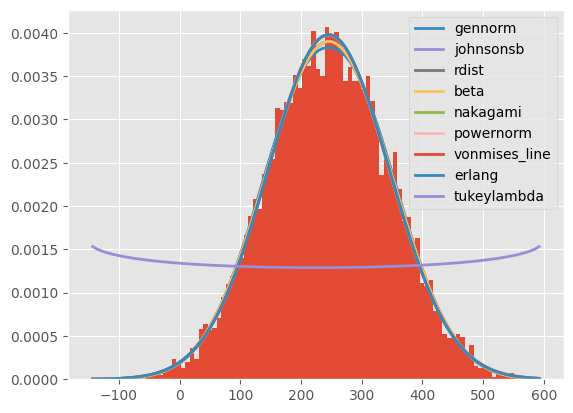

In [ ]:
distribuciones= ['gennorm','johnsonsb','rdist','beta','tukeylambda','gausshyper','nakagami','powernorm','vonmises_line','erlang']
#nakagami, para ver distribuciones electricas
# earlang, usada en teoria de colas

#crear una instancia de fitter para la columna de interes consumo energetico
fitter= Fitter(datos.Consumo_Energetico_Anual, distributions= distribuciones)

#ajustar todas las distribuciones
fitter.fit()

#mostrar un resumen de las mejores distribuciones
fitter.summary(Nbest=10, plot=True)

## Correlacion Entre Variables

Text(0, 0.5, '')

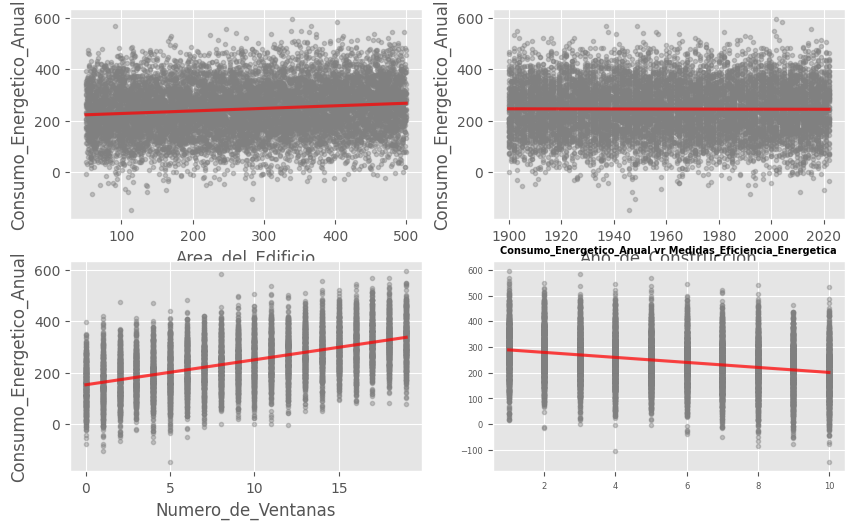

In [ ]:
#Grafico de correlacion para variables numericas

fig, axes= plt.subplots(nrows=2, ncols=2, figsize=(10,6))                     # plotea un grafico 2x2
axes= axes.flat                                                             # enumera los ejes
columnas_numeric= datos.select_dtypes(include=['float','int']).columns
columnas_numeric= columnas_numeric.drop('Consumo_Energetico_Anual')

for i,column in enumerate (columnas_numeric):
  sns.regplot(
      x=datos[column],
      y=datos['Consumo_Energetico_Anual'],
      color='gray',
      marker='.',
      scatter_kws={'alpha':0.4},
      line_kws= {'color':'red','alpha':0.7},
      ax= axes[i]
      )

axes[i].set_title(f'Consumo_Energetico_Anual vr {column}', fontsize=7, fontweight= 'bold')
axes[i].yaxis.set_major_formatter(ticker.EngFormatter())
axes[i].xaxis.set_major_formatter(ticker.EngFormatter())
axes[i].tick_params(labelsize=6)
axes[i].set_xlabel('')
axes[i].set_ylabel('')

# con la grafica resultante estamos observando la tendencia de la

In [ ]:
def matriz_correlacion(corr_mat):
  """ Funcion para convertir una matriz de correlacion en formaro numerico a tipo tidy o dataframe"""
  corr_mat= corr_mat.stack().reset_index()
  corr_mat.columns=['variable_1','variable_2','Correlacion']
  corr_mat=corr_mat.loc[corr_mat['variable_1']!=corr_mat['variable_2'],:]
  corr_mat['Valor Absoluto'] = np.abs(corr_mat['Correlacion'])
  corr_mat= corr_mat.sort_values('Valor Absoluto', ascending=False)

  return(corr_mat)

corr_matriz= datos.select_dtypes(include=['float','int']).corr(method='pearson')
matriz_correlacion(corr_matriz).head(10)


,variable_1,variable_2,Correlacion,Valor Absoluto
22,Consumo_Energetico_Anual,Numero_de_Ventanas,0.556287,0.556287
14,Numero_de_Ventanas,Consumo_Energetico_Anual,0.556287,0.556287
23,Consumo_Energetico_Anual,Medidas_Eficiencia_Energetica,-0.279281,0.279281
19,Medidas_Eficiencia_Energetica,Consumo_Energetico_Anual,-0.279281,0.279281
20,Consumo_Energetico_Anual,Area_del_Edificio,0.129797,0.129797
4,Area_del_Edificio,Consumo_Energetico_Anual,0.129797,0.129797
17,Medidas_Eficiencia_Energetica,Numero_de_Ventanas,0.014345,0.014345
13,Numero_de_Ventanas,Medidas_Eficiencia_Energetica,0.014345,0.014345
11,Numero_de_Ventanas,Ano_de_Construccion,0.013200,0.013200
7,Ano_de_Construccion,Numero_de_Ventanas,0.013200,0.013200


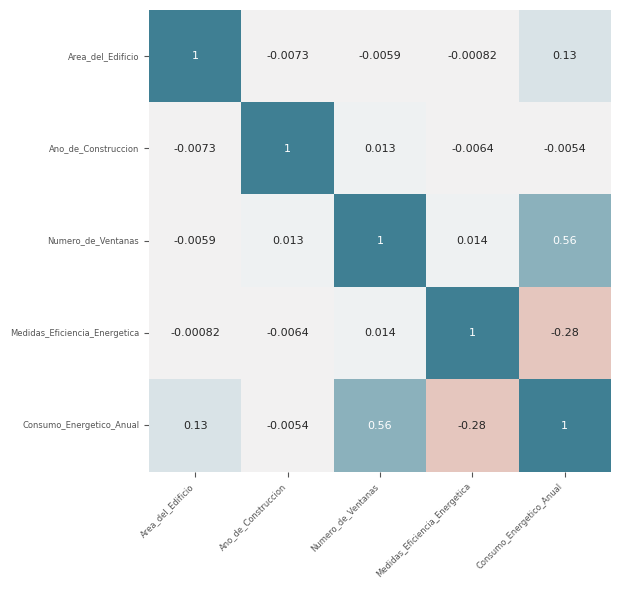

In [ ]:
# Heatmap de matriz de correlaciones, Mapa de Calor

fig,ax= plt.subplots(nrows= 1, ncols=1, figsize=(6,6))

sns.heatmap(
    corr_matriz,
    annot= True,
    cbar= False,
    annot_kws={'size':8},
    vmin= -1,
    vmax= 1,
    center= 0,
    cmap = sns.diverging_palette(20, 220, n=200),
    square=True,
    ax=ax
)

ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=45,
    ha= 'right'
)

ax.tick_params(labelsize= 6)
plt.show()

## Revision Valores Nulos

In [ ]:
# revision de valores nulos o duplicados

datos.isnull().sum()
datos.isna().sum()

Area_del_Edificio                0
Ano_de_Construccion              0
Tipo_de_Aislamiento              0
Numero_de_Ventanas               0
Sistema_Calefaccion              0
Sistema_Refrigeracion            0
Uso_del_Edificio                 0
Ubicacion_Geografica             0
Medidas_Eficiencia_Energetica    0
Consumo_Energetico_Anual         0
dtype: int64

<Axes: >

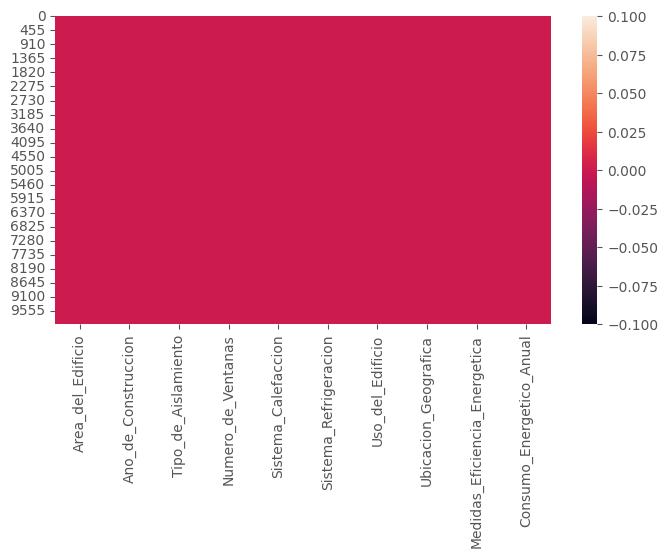

In [ ]:
# revisar los valores vacios con mapa de calor

fig, axes=plt.subplots(figsize=(8,4))

sns.heatmap(datos.isnull())


<Axes: >

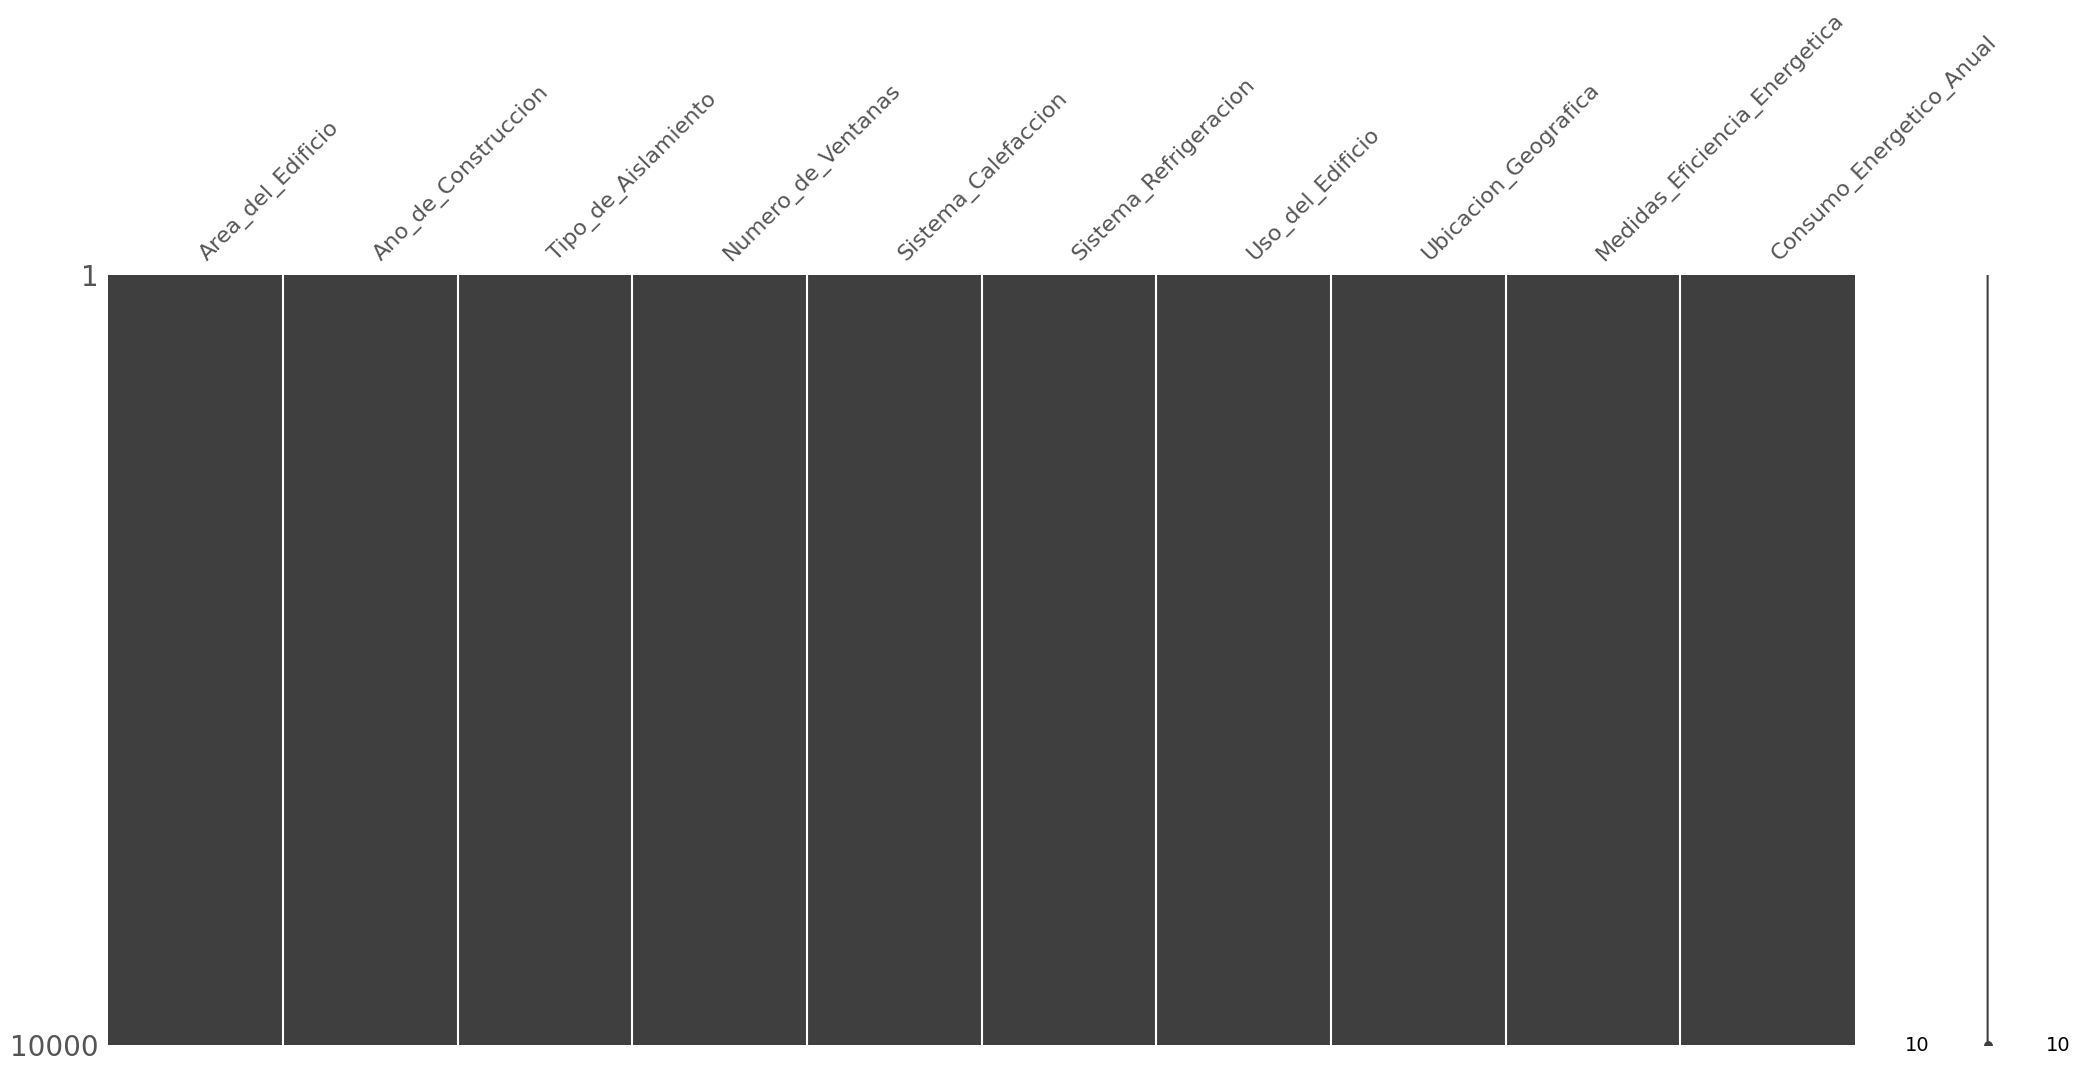

In [ ]:
# trabajando como paquete exclusivo para datos nulos

import missingno as msno

msno.matrix(datos)

# Division Train y Test

Evaluar la capacidad predictiva de un modelo, consiste en comprobar como son las proximas predicciones a los verdaderos valores de la variable respuesta.

Para poder cuantificarlo de forma correcta, se necesita disponer de un conjunto de observaciones, de las que conozca la variable respuesta, pero que el modelo no haya "visto", es decir, que no haya participado en su ajuste. Con esa finalidad se dividen los datos disponibles en un conjunto de entrenamiento y un conjunto de test.

El tamaño adecuado de las particiones depende en gran medida de la cantidad de datos disponibles y la seguridad en la estimacion del error, por lo cual se suele usar 80% y 20% - 70% y 30% que suelen buenos resultado. El reparto debe de hacerse de forma aleatoria o aleatoria estratificada.

In [ ]:
x_train, x_test, y_train, y_test= train_test_split(
    datos.drop('Consumo_Energetico_Anual', axis= 'columns'),
    datos['Consumo_Energetico_Anual'] , # variable Y que queremos predecir
    train_size= 0.8,
    random_state= 1234,     # semilla para generar los n° aleatorio
    shuffle= True          #aplica la aleatoriedad en los datos train y test
)

In [ ]:
print('resultado de la particion de datos train y test, entrenamiento',
'------------------------------------------------------',
y_train.describe(), sep='\n')

resultado de la particion de datos train y test, entrenamiento
------------------------------------------------------
count    8000.000000
mean      245.746697
std       100.286509
min      -146.965665
25%       175.920172
50%       246.689361
75%       314.435114
max       596.204082
Name: Consumo_Energetico_Anual, dtype: float64


In [ ]:
print('resultado de la particion de datos train y test, entrenamiento',
'------------------------------------------------------',
y_test.describe(), sep='\n')

resultado de la particion de datos train y test, entrenamiento
------------------------------------------------------
count    2000.000000
mean      245.363855
std        99.989315
min       -50.774118
25%       176.884601
50%       242.272416
75%       316.332358
max       537.192005
Name: Consumo_Energetico_Anual, dtype: float64


## Reingenieria de Caracteristicas

In [ ]:
# buscar la blibliografia de python para aplicacion normalizacion Z o normalizacion de los minimos
#c uando se tengan datos predictores numericos muy diferente en varianzas.

#encoder pasa de variables categoricas a variables dummies

from sklearn.preprocessing import OneHotEncoder

# Codificacion One-HOt de las variables categoricas
vars_categoricas= x_train.select_dtypes(include=['object']).columns
onehot_encoder= OneHotEncoder(sparse_output=False, drop='first')

# aplicar codificacion al conjunto de datos de entrenamiento y prueba
X_train_codificadas=onehot_encoder.fit_transform(x_train[vars_categoricas])
X_test_codificadas=onehot_encoder.fit_transform(x_test[vars_categoricas])

# convertir los datos transformados en dataframe
datos_X_train_codificados= pd.DataFrame(X_train_codificadas, columns=onehot_encoder.get_feature_names_out(vars_categoricas))
datos_X_test_codificados= pd.DataFrame(X_test_codificadas, columns=onehot_encoder.get_feature_names_out(vars_categoricas))

#unir los datos codificados con los datos numericos
X_train_depurados= pd.concat([x_train.drop(vars_categoricas,axis=1).reset_index(drop=True),datos_X_train_codificados], axis=1)
X_test_depurados= pd.concat([x_test.drop(vars_categoricas,axis=1).reset_index(drop=True),datos_X_test_codificados], axis=1)


In [ ]:
X_train_depurados

,Area_del_Edificio,Ano_de_Construccion,Numero_de_Ventanas,Medidas_Eficiencia_Energetica,Tipo_de_Aislamiento_Básico,Tipo_de_Aislamiento_Moderado,Tipo_de_Aislamiento_Superior,Sistema_Calefaccion_Básico,Sistema_Calefaccion_Moderado,Sistema_Refrigeracion_Básico,...,Uso_del_Edificio_Residencial,Ubicacion_Geografica_Iowa,Ubicacion_Geografica_Maine,Ubicacion_Geografica_Maryland,Ubicacion_Geografica_Michigan,Ubicacion_Geografica_Minnesota,Ubicacion_Geografica_Oklahoma,Ubicacion_Geografica_Pennsylvania,Ubicacion_Geografica_Utah,Ubicacion_Geografica_Vermont
0,448.801123,2008,19,1,1.0,0.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,268.772944,1931,15,4,0.0,1.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,108.279219,1993,2,3,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,245.044198,1995,2,6,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,204.054069,1930,5,1,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7995,231.706733,1909,2,1,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
7996,182.999850,1940,19,4,0.0,0.0,1.0,1.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
7997,270.693795,1905,13,4,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
7998,398.636426,1913,5,6,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Seleccion de Caracteristicas Importantes

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Entrenamiento del modelo
rf_model= RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_depurados, y_train)

#obtener importancia de las caracteristicas
feature_importances= rf_model.feature_importances_

#crea un dataframe para ver las importancias
features_df = pd.DataFrame({
    'Features': X_train_depurados.columns,
    'Importance': feature_importances}).sort_values(by='Importance',ascending=False)

# agregar columna de importancia acumulada
features_df['Importance_Acumulada'] = features_df['Importance'].cumsum()

# mostrar solo las primeras 10 caracteristicas
top_features= features_df.head(10)

top_features




,Features,Importance,Importance_Acumulada
2,Numero_de_Ventanas,0.338607,0.338607
12,Uso_del_Edificio_Residencial,0.107364,0.445972
3,Medidas_Eficiencia_Energetica,0.107113,0.553085
0,Area_del_Edificio,0.089441,0.642525
1,Ano_de_Construccion,0.066027,0.708553
11,Uso_del_Edificio_Industrial,0.059515,0.768067
7,Sistema_Calefaccion_Básico,0.048964,0.817032
9,Sistema_Refrigeracion_Básico,0.042611,0.859643
6,Tipo_de_Aislamiento_Superior,0.025257,0.884900
4,Tipo_de_Aislamiento_Básico,0.024228,0.909128


## Creacion y Entrenamiento del Modelo

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

#seleccion de caracteristicas
select_features= top_features['Features'].values

#print(top_features)

#asegurandonos de seleccionar estas caracteristicas tanto en el conjunto de datos de entrenamiento como de prueba
X_train_selected=X_train_depurados[select_features]
X_test_selected=X_test_depurados[select_features]

#construyendo y entrenado el modelo de regresion lineal
linear_reg= LinearRegression()
linear_reg.fit(X_train_selected, y_train)

LinearRegression()

## Evaluacion del Modelo

se evalua la precision del modelo, la regresion lineal, se identifican diferentes metricas, entre ellas:


*   Error medio absoluto(MAE): media diferencia absoluta entre predicciones y valores reales
*   Error cuadratico medio(MSE): penaliza los errores mas grandes, diferencia entre predicciones y reales.
*   Raiz del error cuadratico medio (RMSE)
*   Coeficiente de determinacion(R2)





In [ ]:
#predecir el conjunto de datos de prueba
y_pred= linear_reg.predict(X_test_selected)

#evaluar Modelo
mse= mean_squared_error(y_test, y_pred)
r2=r2_score(y_test, y_pred)

(mse,r2)

(2954.1518015609913, 0.7043738639467807)

## Probando el Modelo de ML con Datos Nuevos

1ero: se deben preparar los datos de prueba
2do: aplicar el modelo al conjunto de prueba
3er: Evaluar el rendimiento

In [ ]:
# creando una fila de datos ficticios
#asumimos que conocemos las columnas y el tipi de datos basandonos en el conjunto de datos original

new_data_dict={
  'Area_del_Edificio':350.0,        # suponemos un area
  'Ano_de_Construccion': 2023,      # año de construccion el 2023
  'Tipo_de_Aislamiento': 'Avanzado',  # tipo de aislamiento
  'Numero_de_Ventanas': 10,           #numeros de ventanas
  'Sistema_Calefaccion': 'Moderado',  # sistema de calefaccion moderado
  'Sistema_Refrigeracion': 'Avanzado',  # sistema de refrigeraciom
  'Uso_del_Edificio': 'Residencial',
  'Ubicacion_Geografica': 'Utah',
  'Medidas_Eficiencia_Energetica': 5
}

datos_nuevos=pd.DataFrame([new_data_dict])

datos_nuevos


,Area_del_Edificio,Ano_de_Construccion,Tipo_de_Aislamiento,Numero_de_Ventanas,Sistema_Calefaccion,Sistema_Refrigeracion,Uso_del_Edificio,Ubicacion_Geografica,Medidas_Eficiencia_Energetica
0,350.0,2023,Avanzado,10,Moderado,Avanzado,Residencial,Utah,5


In [ ]:
# aplicar transformacion One-Hot Encoding a las variables categoricas
datos_nuevos_codificados= onehot_encoder.transform(datos_nuevos[vars_categoricas])

#convertir a DATAFRAME y seleccionar lar caracteristicas relevantes
datos_nuevos_codificados_df=pd.DataFrame(datos_nuevos_codificados, columns=onehot_encoder.get_feature_names_out(vars_categoricas))
datos_nuevos_depurados= pd.concat([datos_nuevos.drop(vars_categoricas,axis=1).reset_index(drop=True),datos_nuevos_codificados_df],axis=1)
datos_nuevos_seleccionados= datos_nuevos_depurados[select_features]

#hacer la prediccion
predicted_value= linear_reg.predict(datos_nuevos_seleccionados)

predicted_value

array([242.04403411])

In [ ]:
# agregar el valor nuevo a la data
datos_nuevos['prediccion_consumo_energetico']= predicted_value

datos_nuevos

,Area_del_Edificio,Ano_de_Construccion,Tipo_de_Aislamiento,Numero_de_Ventanas,Sistema_Calefaccion,Sistema_Refrigeracion,Uso_del_Edificio,Ubicacion_Geografica,Medidas_Eficiencia_Energetica,prediccion_consumo_energetico
0,350.0,2023,Avanzado,10,Moderado,Avanzado,Residencial,Utah,5,242.044034
